# 06 — Governance: why this agent is allowed to touch money

**The claim this notebook proves:** an ungoverned model in this repository *cannot ship*. Every control below is running code — exercised here live, covered by tests, and enforced by a single CI gate command whose non-zero exit blocks any merge.

| Framework expectation | Implementation in this repo |
|---|---|
| NIST AI RMF — *Govern* | Model card + risk register, generated/validated from real artifacts |
| NIST AI RMF — *Measure* | Coverage & scarcity-recall gates; PSI/KS drift monitor with thresholds |
| NIST AI RMF — *Manage* | Drift acknowledgment loop; one-command rollback; versioned registry |
| EU AI Act — record-keeping | Append-only audit log with SHA-256 hash chain (tamper-evident) |
| EU AI Act — human oversight | HITL approval bound to the schedule's content hash; API refuses without it |
| EU AI Act — transparency | SHAP explanations in market language (notebook 03) |

In [1]:
import json
import shutil
import tempfile
from pathlib import Path

import pandas as pd

from forecast_to_dispatch.config import load_config, resolve_path
from forecast_to_dispatch.governance import audit, check, drift, hitl, risk_register, rollback
from forecast_to_dispatch.viz.style import apply_style

config = load_config()
apply_style()
workdir = Path(tempfile.mkdtemp())  # all demos mutate copies, never real state
audit_log = resolve_path(config, "audit_log")
print("governance runtime dir:", audit_log.parent)

governance runtime dir: C:\Users\alanm\OneDrive\Área de Trabalho\Forecast to Dispatch\governance


## 1. The model card — generated, never hand-written

The card is rebuilt from the registry, training metrics, and backtest results on every governance run, so it can't go stale. Completeness is gate **G1**.

In [2]:
card = (resolve_path(config, "models").parent / "governance" / "model_card.md").read_text(encoding="utf-8")
print(card[:2000])
print("...\n[truncated — full card at governance/model_card.md]")

# Model card — ERCOT price-quantile forecaster (production)

*Generated 2026-07-08 04:40 UTC from `models/registry.json`
and the registered run artifacts. Do not edit by hand — regenerate via
`python -m forecast_to_dispatch.governance.check --refresh-artifacts`.*

**Model version:** `lgbm_20240503` (challenger: `lstm_20240503`,
previous: `none`)

## Intended use

Day-ahead probabilistic forecasting of hourly ERCOT real-time settlement point
prices at HB_HOUSTON, issued 09:00 D-1, to drive co-optimized
energy + ancillary-service dispatch of a 100 MW /
200 MWh battery. **Not** for financial trading advice, other
hubs/ISOs without revalidation, or intraday re-forecasting.

## Training data

Public ERCOT archives via `gridstatus` (no paid/proprietary data): DAM and RTM
settlement point prices, DAM ancillary clearing prices (Reg Up/Down, RRS,
Non-Spin, ECRS), hourly system load, and wind/solar generation.
Training window: 2024-01-09 → 2024-05-03
(2,760 hourly observations, 28 leakage-safe f

## 2. The risk register — schema-validated source of truth

Ten risks, each with likelihood/impact/mitigation/owner; a malformed or empty register fails gate **G2** (a silent gap in the register is itself a risk).

In [3]:
from forecast_to_dispatch.config import REPO_ROOT
risks = risk_register.load_register(REPO_ROOT / "governance" / "risk_register.yaml")
pd.DataFrame(risks)[["id", "title", "likelihood", "impact", "status", "owner"]]

,id,title,likelihood,impact,status,owner
0,R1,Forecast miss during a scarcity event,medium,high,mitigated-monitored,model-owner
1,R2,"Market regime drift (weather, fuel, fleet change)",high,high,mitigated-monitored,model-owner
2,R3,State-of-charge or reserve constraint violation,low,high,mitigated,dispatch-owner
3,R4,"Market rule change (RTC+B evolution, product r...",medium,medium,accepted-with-controls,market-owner
4,R5,Data outage or archive expiry,medium,medium,mitigated,data-owner
5,R6,Future leakage in features,medium,high,mitigated,model-owner
6,R7,Overconfident uncertainty intervals,medium,high,mitigated-monitored,model-owner
7,R8,Unapproved or tampered dispatch reaching deplo...,low,high,mitigated,operations-owner
8,R9,Bad model version in serving,medium,medium,mitigated,operations-owner
9,R10,Optimizer failure or pathological solution,low,medium,mitigated,dispatch-owner


## 3. The drift monitor — and the summer it caught

PSI + KS on key features and the model's own P50 output, weekly windows vs the training reference (fig11). During this build the monitor **fired for real**: late-June net load drifted to PSI ≈ 4.8 against the Jan–Apr reference — the ERCOT summer arriving, exactly the regime shift risk R2 describes.

The governed response is not to tune thresholds until green. Gate **G6** fails on *unacknowledged* drift; it passes only because a named owner recorded a reasoned, expiring acknowledgment (`governance/drift_acknowledgment.yaml`): the study model is deliberately frozen, its honesty on the drifted window is independently verified (coverage 0.86, capture 86.1% *on that window*), and the production action would be retraining. Detect → human decision → documented acceptance, all version-controlled.

In [4]:
X = pd.read_parquet(resolve_path(config, "processed") / "features.parquet")
registry = json.loads((resolve_path(config, "models") / "registry.json").read_text())
metrics = json.loads((resolve_path(config, "models") / registry["current"] / "metrics.json").read_text())
train_end = pd.Timestamp(metrics["train_window"][1])

report = drift.drift_report(
    X.loc[X.index <= train_end], X.loc[X.index > train_end].iloc[-14 * 24:],
    drift.MONITORED_FEATURES,
    config["governance"]["drift"]["psi_threshold"],
    config["governance"]["drift"]["ks_pvalue_threshold"],
)
report

,psi,ks_pvalue,psi_alert,ks_alert,drift
series,,,,,
rtm_lag48,2.3445,2.485263e-52,True,True,True
rtm_roll24_std,1.7309,6.425939e-09,True,True,True
dam_lag24,2.3019,7.071205e-47,True,True,True
net_load_lag48,4.7544,1.428308e-90,True,True,True


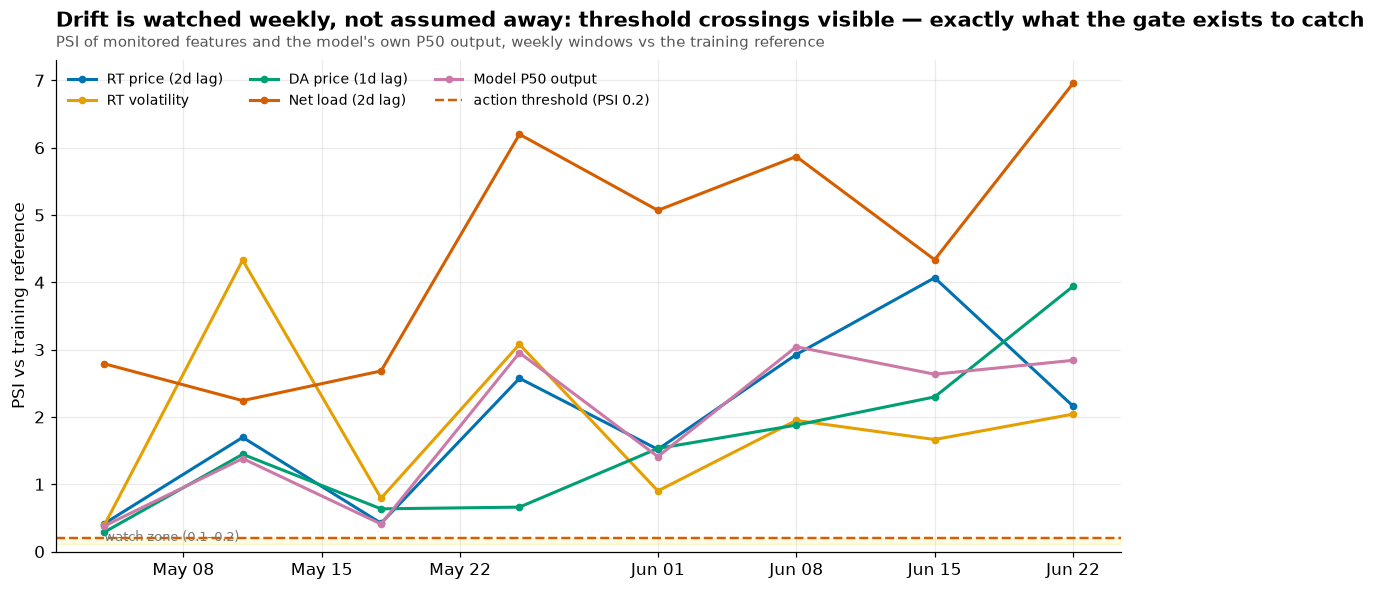

In [5]:
# fig11 inline: weekly PSI of monitored features + the model's own P50 output
from forecast_to_dispatch.forecast.conformal import ConformalizedForecaster
from forecast_to_dispatch.viz.governance_viz import fig11_drift_monitor

model = ConformalizedForecaster.load(resolve_path(config, "models") / registry["current"])
frame = X[drift.MONITORED_FEATURES].copy()
frame["prediction_q50"] = model.predict_quantiles(X)["q50"]
rolling = drift.rolling_psi(frame.loc[frame.index <= train_end],
                            frame.loc[frame.index > train_end], list(frame.columns))
fig = fig11_drift_monitor(rolling, config["governance"]["drift"]["psi_threshold"])

## 4. The audit trail — append-only, tamper-evident

Every decision (forecast → schedule → approval → settlement) is a JSONL record embedding the SHA-256 of its predecessor. Below: the real chain verifies; then we *attack* a temp copy by rewriting one historical record — and the chain breaks exactly where the edit happened.

In [6]:
ok, detail = audit.verify_chain(audit_log)
print("real log:", ok, "-", detail)

# Attack a COPY: rewrite history and watch verification fail
attacked = workdir / "attacked.jsonl"
shutil.copy(audit_log, attacked)
lines = attacked.read_text().strip().splitlines()
doctored = json.loads(lines[1])
doctored["payload"]["expected_profit"] = 999999.0   # inflate the record
lines[1] = json.dumps(doctored, sort_keys=True)
attacked.write_text("\n".join(lines) + "\n")
print("attacked copy:", *audit.verify_chain(attacked))

real log: True - 4 records verified
attacked copy: False record 1 content does not match its hash (tampered)


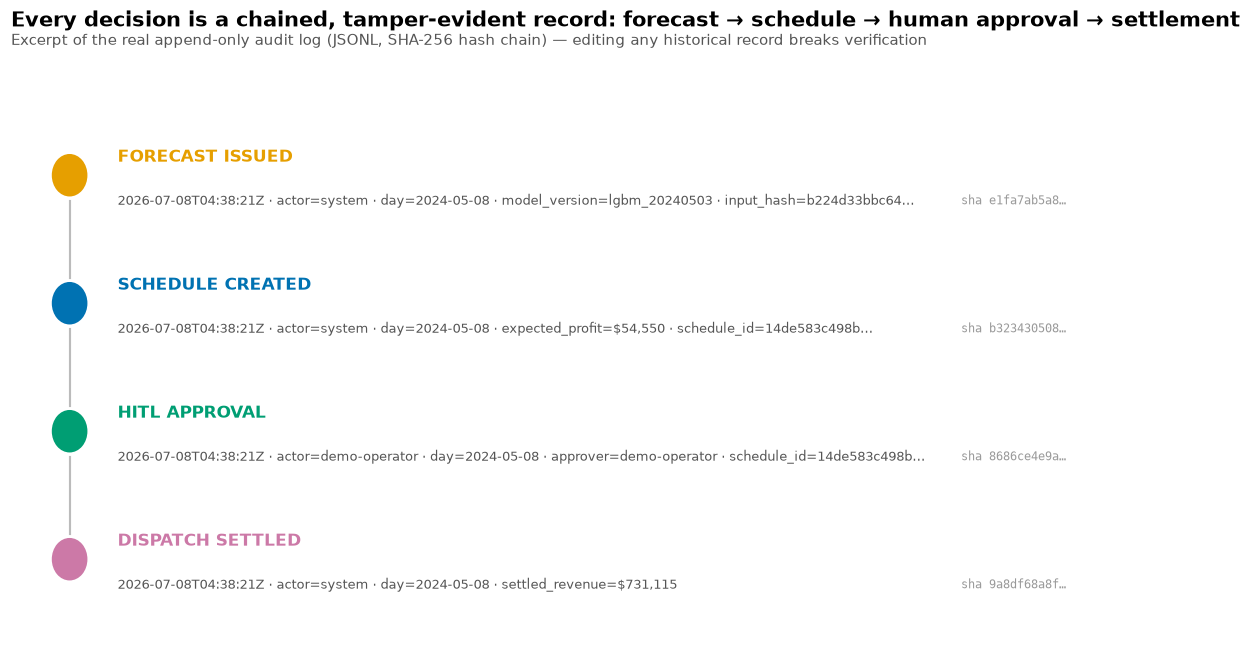

In [7]:
from forecast_to_dispatch.viz.governance_viz import fig24_audit_trail_flow
fig = fig24_audit_trail_flow(audit.read_log(audit_log))

## 5. Human-in-the-loop — approval is bound to the schedule's hash

A schedule is identified by the hash of its content. No approval → `PermissionError`. Approve it → deployable. Change **one megawatt** → it is a different schedule and the approval no longer applies. The serving API (Phase 7) enforces this same gate.

In [8]:
schedule = pd.read_parquet(resolve_path(config, "processed") / "dispatch_day_schedule.parquet")
demo_approvals = workdir / "approvals.json"
demo_log = workdir / "audit.jsonl"

try:
    hitl.require_approval(schedule, demo_approvals)
except PermissionError as e:
    print("BLOCKED:", str(e)[:90], "...")

rec = hitl.approve_schedule(schedule, "walkthrough-operator", demo_approvals, demo_log)
print("APPROVED by", rec["approver"], "for schedule", rec["schedule_id"][:12], "...")
print("deployable now:", hitl.is_approved(schedule, demo_approvals))

tampered = schedule.copy()
tampered.iloc[19, tampered.columns.get_loc("discharge_mw")] += 1.0  # one MW
try:
    hitl.require_approval(tampered, demo_approvals)
except PermissionError:
    print("TAMPERED schedule (one MW changed) correctly BLOCKED — approval didn't transfer")

BLOCKED: Schedule 14de583c498b... is NOT deployable: no human approval on record. A dispatch schedu ...
APPROVED by walkthrough-operator for schedule 14de583c498b ...
deployable now: True
TAMPERED schedule (one MW changed) correctly BLOCKED — approval didn't transfer


## 6. Rollback — one command back to the last known-good model

The registry keeps `current` and `previous` pointers; rollback swaps them and audits the act. Demo on a copy of the real registry:

In [9]:
demo_models = workdir / "models"
demo_models.mkdir()
real_models = resolve_path(config, "models")
reg = json.loads((real_models / "registry.json").read_text())
reg["previous"] = reg["challenger"]          # give the demo a previous version
for mid in (reg["current"], reg["previous"]):
    (demo_models / mid).mkdir()
(demo_models / "registry.json").write_text(json.dumps(reg, indent=2))

print("before:", json.loads((demo_models / "registry.json").read_text())["current"])
rollback.rollback(demo_models, workdir / "audit.jsonl", actor="walkthrough-operator",
                  reason="demo: drift alarm playbook")
print("after :", json.loads((demo_models / "registry.json").read_text())["current"])
print("audited:", audit.read_log(workdir / "audit.jsonl")[-1]["event_type"])

before: lgbm_20240503
after : lstm_20240503
audited: model_rollback


## 7. The single release gate

Everything funnels into one command — `python -m forecast_to_dispatch.governance.check` — nine gates, non-zero exit on any failure. CI runs exactly this; the matrix below is the live verdict on the current artifacts.

In [10]:
all_pass, results = check.run_gates(config)
for r in results:
    print(f"{r['gate']}  {'PASS' if r['passed'] else 'FAIL'}  {r['name']:<28} {r['detail'][:80]}")
print("\nRELEASE:", "permitted" if all_pass else "BLOCKED")
assert all_pass

G1  PASS  model card complete          complete
G2  PASS  risk register valid          10 risks, schema valid
G3  PASS  interval coverage honest     coverage_90=0.855, tolerance ±0.08 around 0.90
G4  PASS  scarcity recall reported     scarcity_recall=0.35 on 17 hours
G5  PASS  leakage spec intact          all declared lags legal
G6  PASS  drift within thresholds      drift DETECTED in ['rtm_lag48', 'rtm_roll24_std', 'dam_lag24', 'net_load_lag48']
G7  PASS  audit chain verifies         4 records verified
G8  PASS  backtest capture plausible   capture=86.1%, governed>naive=True
G9  PASS  model registry consistent    current=lgbm_20240503

RELEASE: permitted


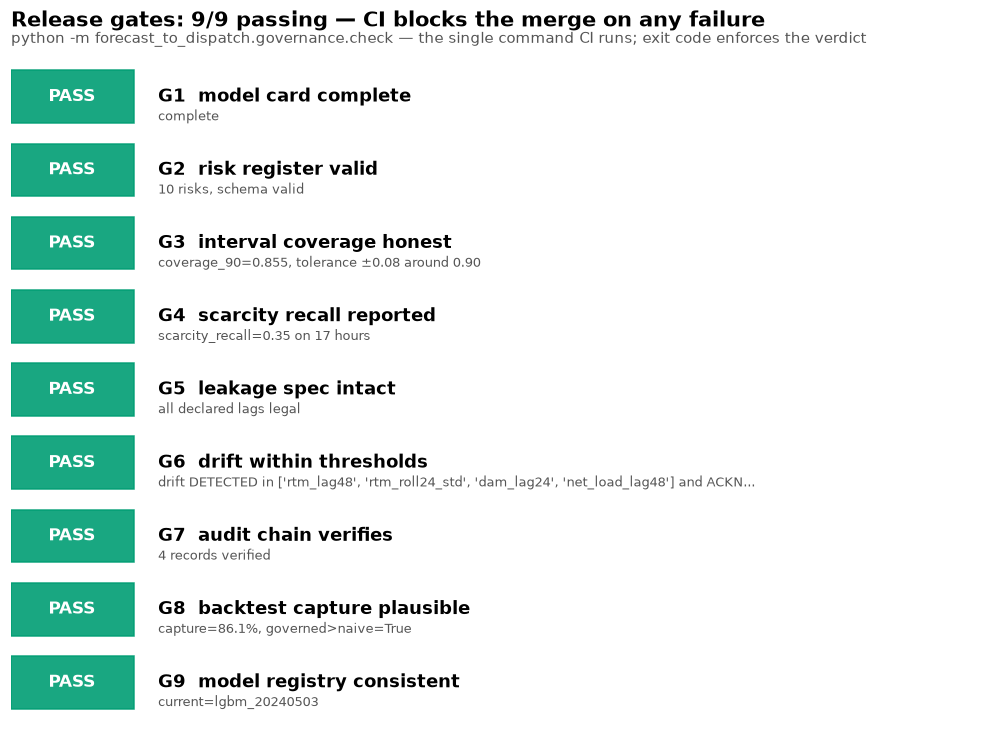

In [11]:
from forecast_to_dispatch.viz.governance_viz import fig12_gate_status
fig = fig12_gate_status(results)

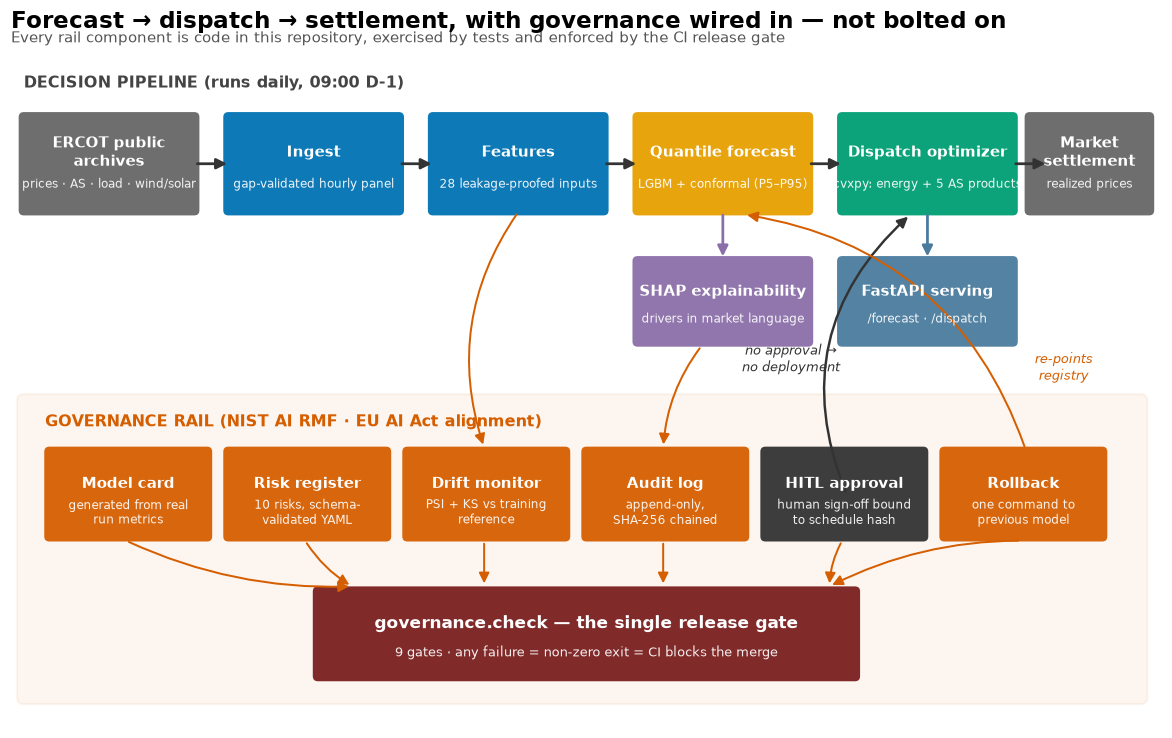

In [12]:
from forecast_to_dispatch.viz.architecture import fig13_architecture
fig = fig13_architecture()

## Takeaways

1. **Every control is code**: card, register, drift, audit, HITL, rollback — all demonstrated live above, all covered by `tests/test_governance.py`.
2. **The drift monitor caught a real regime shift** during the build, and the response is documented governance, not threshold-tuning.
3. **Tampering is detectable, oversight is unavoidable, recovery is one command** — the three properties an asset owner, an ISO, or an AI-Act auditor actually asks for.

Next: `serve/api.py` wires these same gates into a FastAPI service, and CI (Phase 8) makes the gate command a required check.